In [1]:
import moabb
from moabb.datasets import BNCI2014008
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler

In [2]:
paradigm = P300(tmin=-3.2, tmax=4, resample=None, fmax=None)
dataset = BNCI2014008()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied
0 bad epochs dropped


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-3.199 – 4.000 sec
Baseline,off


In [4]:
scaler= Scaler(scalings='mean', with_mean=False)
epochs._data = scaler.fit_transform(epochs._data)

In [5]:
#_=epochs.plot_psd()

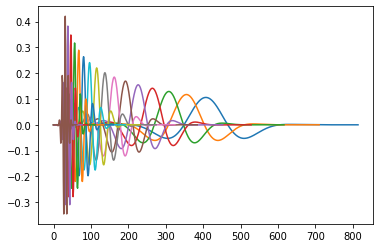

In [6]:
n_freqs=16
freqs= np.geomspace(1, 32, n_freqs)
n_cycles = np.linspace(2, 5, n_freqs)
wavelets = morlet(epochs.info['sfreq'],
                  freqs, n_cycles, zero_mean=True)
for i in range(n_freqs):
    plt.plot(np.real(wavelets[i]))

In [7]:
sfreq=16
epochs = tfr_morlet(epochs, freqs, n_cycles, return_itc=False, average=False,
                    output='complex', verbose=True, n_jobs=12, decim=int(epochs.info['sfreq']//sfreq))
epochs.crop(0, 1.0)
epochs

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   3 out of   8 | elapsed:   28.5s remaining:   47.5s
[Parallel(n_jobs=12)]: Done   5 out of   8 | elapsed:   31.6s remaining:   18.9s
[Parallel(n_jobs=12)]: Done   8 out of   8 | elapsed:   34.7s finished


Not setting metadata


<EpochsTFR | time : [-0.011719, 0.988281], freq : [1.000000, 32.000000], epochs : 4200, channels : 8, ~139.5 MB>

In [8]:
#epochs.data = np.abs(epochs.data)
#epochs.data/=freqs[np.newaxis,np.newaxis,:,np.newaxis]


No baseline correction applied
No baseline correction applied


/tmp/ipykernel_19878/175981033.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_19878/175981033.py:12: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


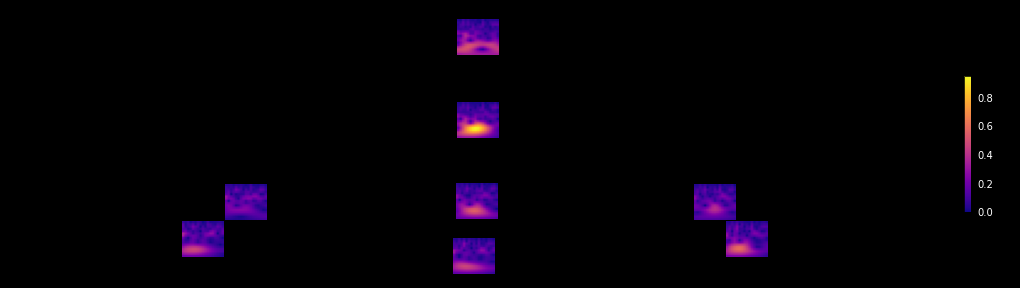

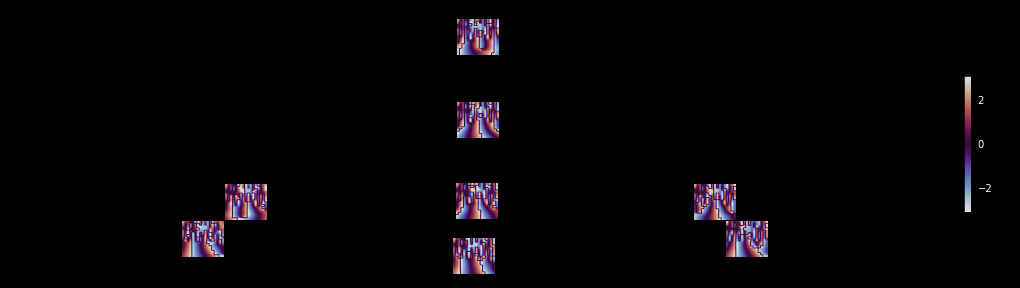

In [9]:
class_names = np.unique(labels)
contrast = epochs[class_names[1]].average() - epochs[class_names[0]].average()
contrast_m = contrast.copy()
contrast_m.data = np.abs(contrast_m.data)
fig = contrast_m.plot_topo(show=False, cmap='plasma', vmin=0)
fig.set_figwidth(16)
fig.show()
contrast_p = contrast.copy()
contrast_p.data = np.angle(contrast_p.data)
fig = contrast_p.plot_topo(show=False, cmap='twilight')
fig.set_figwidth(16)
fig.show()

In [10]:
X = epochs.data.astype(np.complex128)
y = labels

In [11]:
hoda = HODA(max_iter=128, rank=(2,2,2), tol=1e-12, initialize ='random', verbose=True, toeplitz=2, taper=2, shrinkage='oas')
%prun hoda.fit(X,y)

Iteration 0  updates: [4.34983326 6.0230756  5.75266534]
Iteration 1  updates: [3.61388816 6.1991532  4.49189224]
Iteration 2  updates: [4.88287733 5.69893579 4.99156412]
Iteration 3  updates: [5.72179437 4.11422472 5.71514743]
Iteration 4  updates: [6.28506957 3.75819618 5.35601905]
Iteration 5  updates: [1.60149164 2.88715427 5.06466274]
Iteration 6  updates: [4.29492904 3.19273816 8.89804161]
Iteration 7  updates: [4.58816675 3.77105988 9.94609009]
Iteration 8  updates: [5.84003167 7.69674069 6.80485754]
Iteration 9  updates: [4.51529302 8.19223385 5.48193102]
Iteration 10  updates: [ 6.60415874 12.72279484  6.48789775]
Iteration 11  updates: [6.19352719 7.86448813 5.34094942]
Iteration 12  updates: [4.41273681 3.6869925  4.94538135]
Iteration 13  updates: [5.14723946 5.84285121 6.54513291]
Iteration 14  updates: [4.5188423  4.31440261 6.43430601]
Iteration 15  updates: [3.85453778 4.915151   6.92656681]
Iteration 16  updates: [3.48129889 3.80672975 7.17663506]
Iteration 17  updates

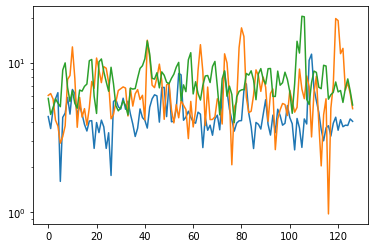

In [12]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

(2, 2, 2)


/tmp/ipykernel_19878/3249753551.py:19: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


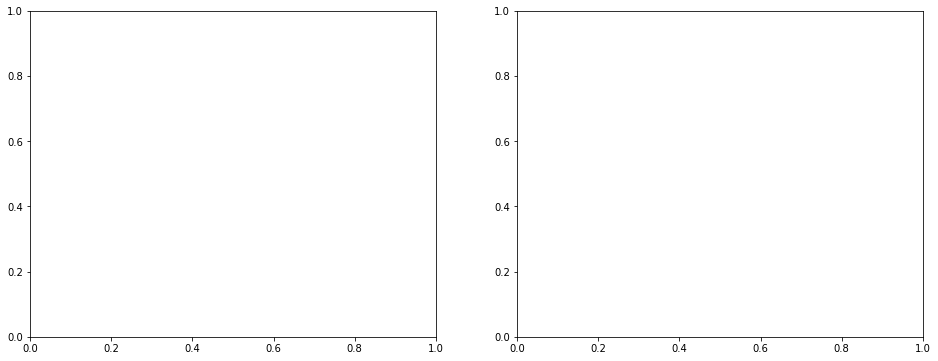

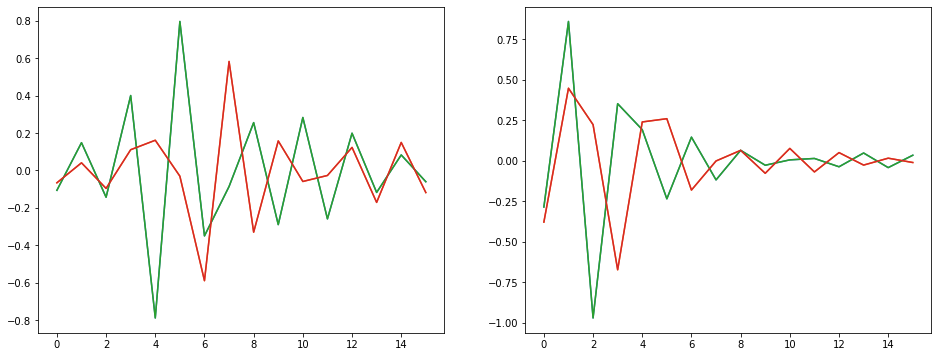

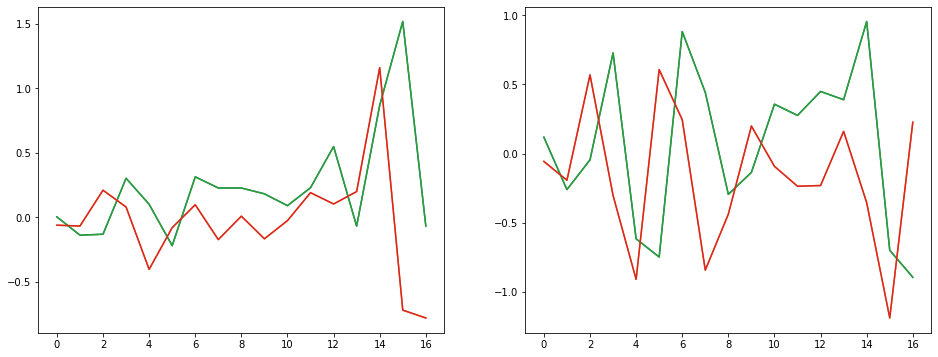

In [13]:
print(hoda.rank_)
for k in range(3):
    Uk = hoda.projs_[k]
    vmax = np.max(np.abs(Uk))
    fig, axs = plt.subplots(1,Uk.shape[1], figsize=(16,6))
    if Uk.shape[1]==1:
        axs = [axs]
    for i in range(Uk.shape[1]):
        if k==0:
            #plot_topomap(Uk[:,i], epochs.info, axes=axs[i], show=False)        
            pass
        elif k == 2 or k==1:
            for i in range(Uk.shape[1]):
                axs[i].plot(np.real(Uk[:,i]))
                axs[i].plot(np.imag(Uk[:,i]))

        else:
            sns.heatmap(Uk, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()

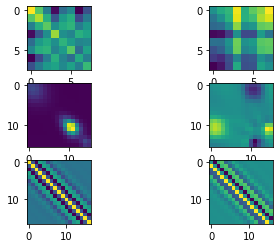

In [14]:
fig, axs = plt.subplots(3,2)
for k in range(3):
    axs[k,0].imshow(np.real(hoda.scatter_w_[k]))
    axs[k,1].imshow(np.imag(hoda.scatter_w_[k]))


(2, 2, 2)


/tmp/ipykernel_19878/2750000873.py:19: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


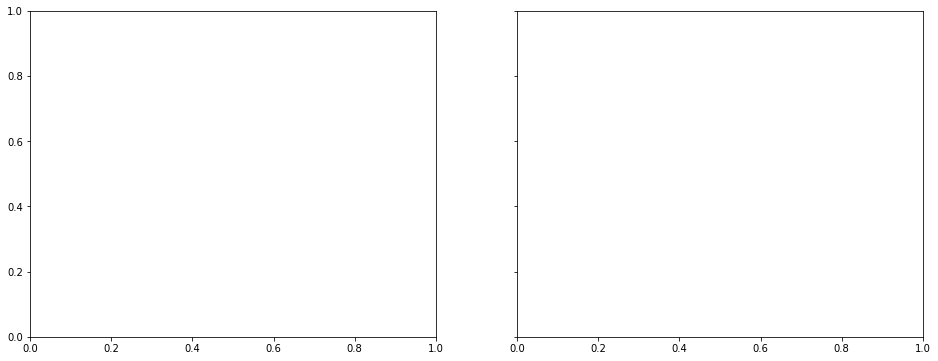

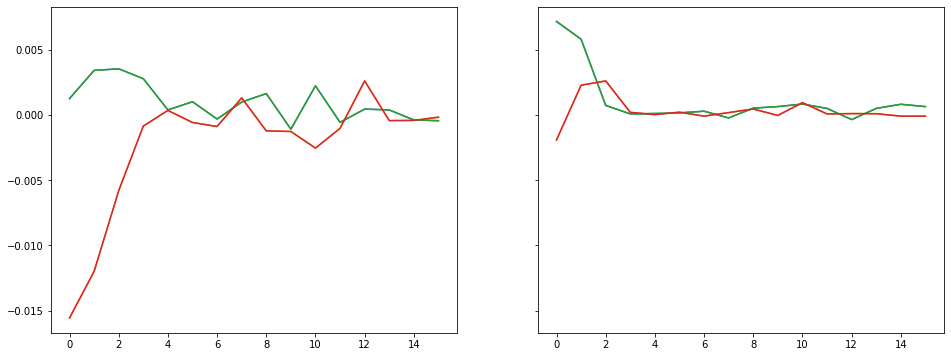

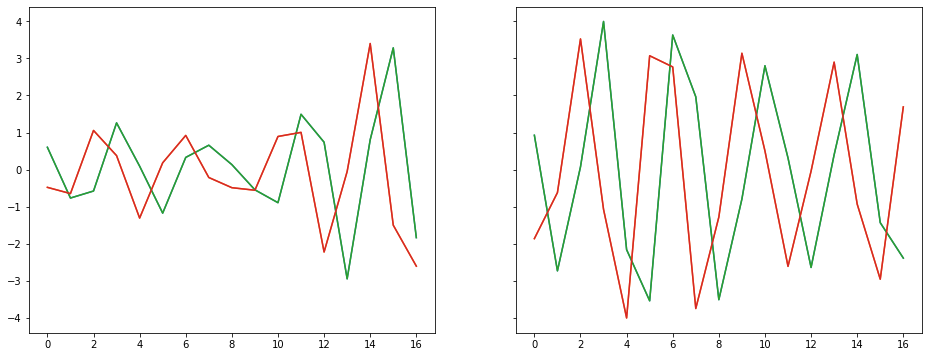

In [15]:
print(hoda.rank_)
for k in range(3):
    patterns = (hoda.projs_[k].T@hoda.scatter_w_[k]).T
    vmax = np.max(np.abs(patterns))
    fig, axs = plt.subplots(1,patterns.shape[1], figsize=(16,6), sharex=True, sharey=True)
    if patterns.shape[1]==1:
        axs = [axs]
    for i in range(patterns.shape[1]):
        if k==0:
            #plot_topomap(patterns[:,i], epochs.info, axes=axs[i], show=False)        
            pass
        elif k == 2 or k==1:
            for i in range(patterns.shape[1]):
                axs[i].plot(np.real(patterns[:,i]))
                axs[i].plot(np.imag(patterns[:,i]))
        else:
            sns.heatmap(patterns, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()

In [16]:
Xt = hoda.transform(X)
Xt = np.hstack([np.real(Xt), np.imag(Xt)]).astype(np.float64)

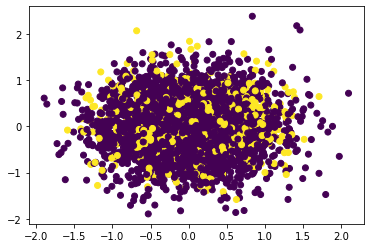

In [17]:
pca = PCA(n_components=2)
X_pc = pca.fit_transform(Xt)
plt.scatter(X_pc[:,0], X_pc[:,1],c=labels=='Target')

In [18]:
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
lda.fit(Xt,y)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [19]:
roc_auc_score(y, lda.predict_proba(Xt)[:,1])

0.662584081632653